0.30115715557313816 0.006478093165858965


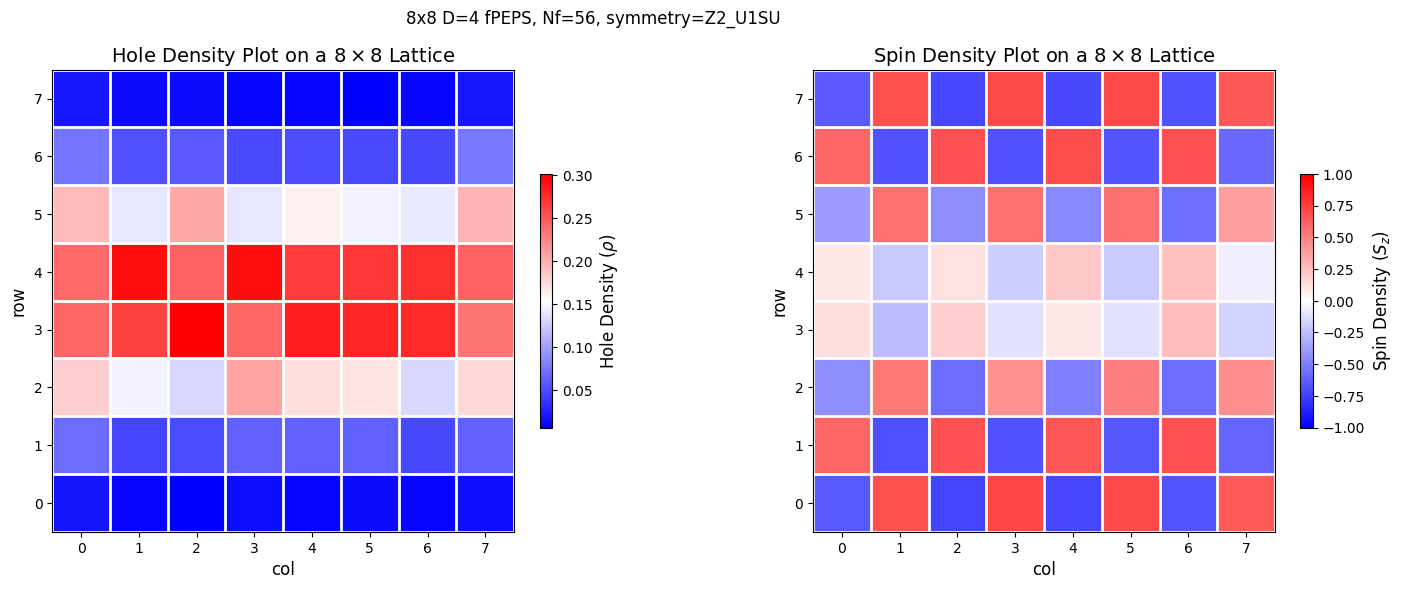

In [4]:
import numpy as np
from vmc_torch.experiment.tn_model import fTNModel_reuse
pwd = '/home/sijingdu/TNVMC/VMC_code/vmc_torch/data'
# Hamiltonian parameters
Lx = int(8)
Ly = int(8)
symmetry = 'U1SU'
appendix = ''
if symmetry == 'U1SU':
    symmetry = 'Z2'
    appendix = '_U1SU'
t = 1.0
U = 8.0
N_f = int(Lx*Ly-8)
n_fermions_per_spin = (N_f//2, N_f//2)
# TN parameters
D = 4
chi = 4*D
model_names = {
    fTNModel_reuse: 'fTN_reuse'+appendix,
}
model_name = model_names[fTNModel_reuse]
configs = np.load(pwd+f'/{Lx}x{Ly}/t={t}_U={U}/N={N_f}/{symmetry}/D={D}/{model_name}/chi={chi}/sampled_configs.npy')

def charge_map(config):
    mapping = {0:0, 1:1, 2:1, 3:2}
    return np.vectorize(mapping.get)(config)

def hole_map(config):
    mapping = {0:1, 1:0, 2:0, 3:-1}
    return np.vectorize(mapping.get)(config)

def spin_map(config):
    mapping = {0:0, 1:1, 2:-1, 3:0}
    return np.vectorize(mapping.get)(config)

# charge_configs = charge_map(configs)
charge_configs = hole_map(configs)
spin_configs = spin_map(configs)

avg_charge_config = np.mean(charge_configs, axis=0)
avg_spin_config = np.mean(spin_configs, axis=0)

# reshape to 2D lattice
avg_charge_config_2d = avg_charge_config.reshape((Lx, Ly))
avg_spin_config_2d = avg_spin_config.reshape((Lx, Ly))

import matplotlib.pyplot as plt
# 3. Create the heatmap plot
fig, ax = plt.subplots(1, 2, figsize=(18, 6))
im = ax[0].imshow(avg_charge_config_2d, cmap='bwr', aspect='equal', origin='lower')

# 4. Add a colorbar and labels to the first plot
cbar = fig.colorbar(im, ax=ax[0], orientation='vertical', fraction=0.02, pad=0.04)
# Use raw string 'r' for LaTeX in the label
cbar.set_label(r'Hole Density ($\rho$)', fontsize=12)

# Set title and labels, using raw string 'r' for LaTeX
ax[0].set_title(rf'Hole Density Plot on a ${Lx} \times {Ly}$ Lattice', fontsize=14)
ax[0].set_xlabel('col', fontsize=12)
ax[0].set_ylabel('row', fontsize=12)

# Set ticks to represent the lattice sites, centered on the cells
ax[0].set_xticks(np.arange(Ly))
ax[0].set_yticks(np.arange(Lx))

# Add a grid to delineate the cells clearly
ax[0].set_xticks(np.arange(Ly+1)-0.5, minor=True)
ax[0].set_yticks(np.arange(Lx+1)-0.5, minor=True)
ax[0].grid(which="minor", color="w", linestyle='-', linewidth=2)
ax[0].tick_params(which="minor", bottom=False, left=False)


im2 = ax[1].imshow(avg_spin_config_2d, cmap='bwr', aspect='equal', origin='lower', vmin=-1, vmax=1)
# 4. Add a colorbar and labels
cbar2 = fig.colorbar(im2, ax=ax[1], orientation='vertical',
                        fraction=0.02, pad=0.04)    
# Use raw string 'r' for LaTeX in the label
cbar2.set_label(r'Spin Density ($S_z$)', fontsize=12)
# Set title and labels, using raw string 'r' for LaTeX
ax[1].set_title(rf'Spin Density Plot on a ${Lx} \times {Ly}$ Lattice', fontsize=14)
ax[1].set_xlabel('col', fontsize=12)
ax[1].set_ylabel('row', fontsize=12)
# Set ticks to represent the lattice sites, centered on the cells
ax[1].set_xticks(np.arange(Ly))
ax[1].set_yticks(np.arange(Lx))
# Add a grid to delineate the cells clearly
ax[1].set_xticks(np.arange(Ly+1)-0.5, minor=True)
ax[1].set_yticks(np.arange(Lx+1)-0.5, minor=True)
ax[1].grid(which="minor", color="w", linestyle='-', linewidth=2)
ax[1].tick_params(which="minor", bottom=False, left=False)  
plt.suptitle(f'{Lx}x{Ly} D={D} fPEPS, Nf={N_f}, symmetry={symmetry}{appendix}')
# plt.show()
# plt.savefig(f'./D={D}_chi={chi}_pf_w_mid_2_rows', dpi=300)
print(avg_charge_config_2d.max(), avg_charge_config_2d.min())

In [7]:
configs[1]

array([2., 1., 2., 1., 2., 1., 2., 1., 1., 1., 1., 2., 1., 2., 2., 1., 2.,
       2., 0., 2., 0., 1., 0., 0., 2., 0., 2., 1., 2., 0., 2., 1., 1., 0.,
       1., 2., 1., 1., 1., 2., 2., 1., 2., 1., 2., 0., 2., 1., 1., 3., 2.,
       3., 1., 2., 1., 2., 2., 1., 0., 2., 0., 1., 2., 1.])